In [22]:
import matplotlib as pl
import matplotlib.pyplot as plt
import pandas as pd
import sklearn as sc
import scipy as sp
import numpy as np
import seaborn as sns
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster
from sklearn.cluster import DBSCAN
from sklearn.metrics import pairwise_distances




# Aufgabe B2
## Teil 1

In [23]:
# Team A: Einfuehrung der Daten
daten = pd.DataFrame(
    {
        "x": [12, 6, 4, 1, 0, 3, 6],
        "y": [2, 1, 10, 6, 3, 0, 12],
    },
    index=[f"P{i}" for i in range(7)],
)

display(daten)

,x,y
P0,12,2
P1,6,1
P2,4,10
P3,1,6
P4,0,3
P5,3,0
P6,6,12


#### a)

In [24]:
# Paarweise euklidische Distanzmatrix
pairwise_distance = pairwise_distances(daten[["x", "y"]], metric="euclidean")
distanzmatrix = pd.DataFrame(pairwise_distance, index=daten.index, columns=daten.index)

# Kleinste Distanz ohne Hauptdiagonale bestimmen
distanz_ohne_diagonale = pairwise_distance.copy()
np.fill_diagonal(distanz_ohne_diagonale, np.inf)
i, j = np.unravel_index(np.argmin(distanz_ohne_diagonale), distanz_ohne_diagonale.shape)

punkt_1 = daten.index[i]
punkt_2 = daten.index[j]
min_distanz = pairwise_distance[i, j]

display(
    distanzmatrix.style
    .format("{:.2f}")
    .background_gradient(cmap="Blues")
    .set_caption("Paarweise euklidische Distanzmatrix")
)

ergebnis = pd.DataFrame(
    {
        "Punkt 1": [punkt_1],
        "Punkt 2": [punkt_2],
        "Distanz": [round(min_distanz, 4)],
    }
)

display(ergebnis.style.hide(axis="index").set_caption("Naechstes Punktepaar"))

,P0,P1,P2,P3,P4,P5,P6
P0,0.00,6.08,11.31,11.70,12.04,9.22,11.66
P1,6.08,0.00,9.22,7.07,6.32,3.16,11.00
P2,11.31,9.22,0.00,5.00,8.06,10.05,2.83
P3,11.70,7.07,5.00,0.00,3.16,6.32,7.81
P4,12.04,6.32,8.06,3.16,0.00,4.24,10.82
P5,9.22,3.16,10.05,6.32,4.24,0.00,12.37
P6,11.66,11.00,2.83,7.81,10.82,12.37,0.00


Punkt 1,Punkt 2,Distanz
P2,P6,2.828400


#### b)

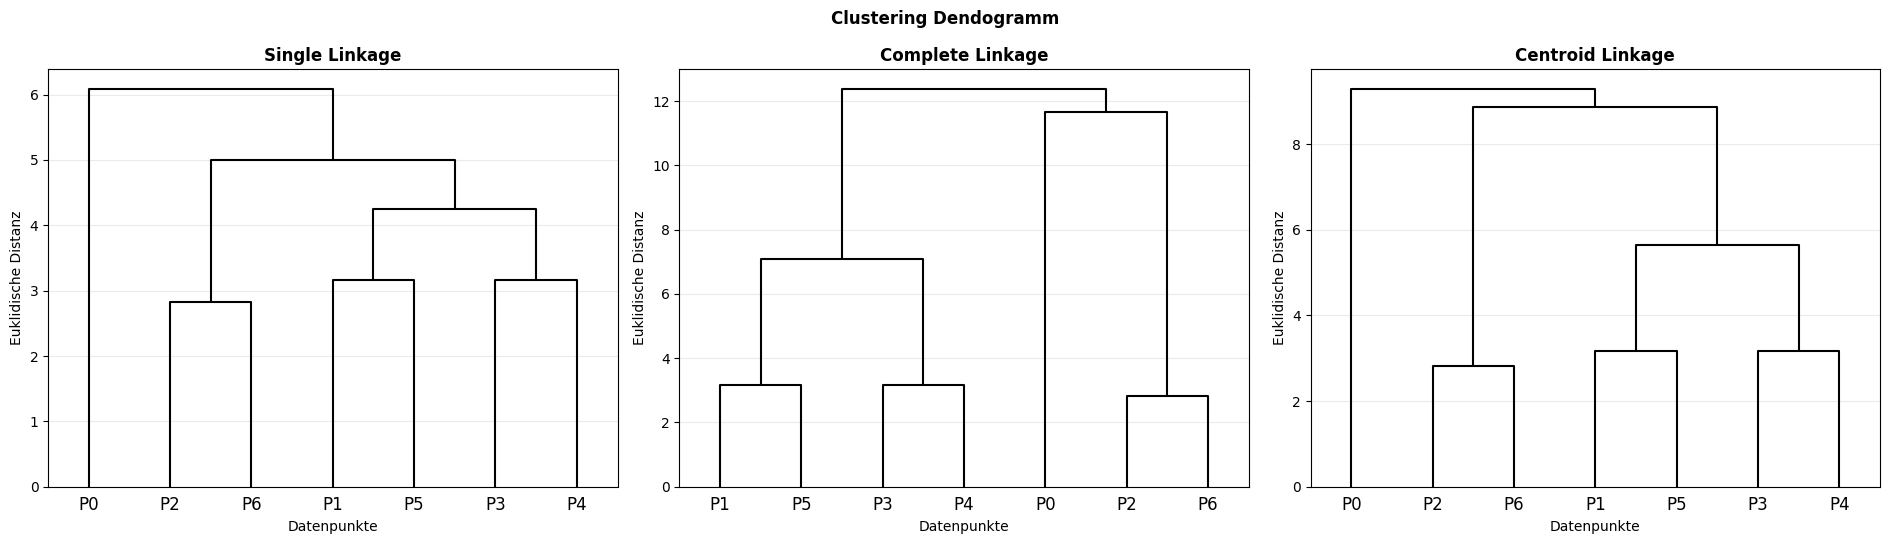

In [25]:
# Agglomeratives Clustering mit drei Linkage-Verfahren
linkage_verfahren = {
    "Single Linkage": "single",
    "Complete Linkage": "complete",
    "Centroid Linkage": "centroid",
}

linkage_matrizen = {}

fig, axes = plt.subplots(1, 3, figsize=(19, 5.5))

for ax, (titel, methode) in zip(axes, linkage_verfahren.items()):
    Z = linkage(daten[["x", "y"]], method=methode, metric="euclidean")
    linkage_matrizen[methode] = Z

    dendrogram(
        Z,
        labels=daten.index.tolist(),
        ax=ax,
        color_threshold=0,
        above_threshold_color="black",
    )
    ax.set_title(titel, fontweight="bold")
    ax.set_xlabel("Datenpunkte")
    ax.set_ylabel("Euklidische Distanz")
    ax.grid(axis="y", alpha=0.25)

fig.suptitle("Vollstaendige Dendrogramme des agglomerativen Clusterings", fontweight="bold")
plt.tight_layout()
plt.show()

In [26]:
# Vergleich der Verfahren bei einer sinnvollen Interpretation mit zwei Clustern
vergleich = []

for titel, methode in linkage_verfahren.items():
    cluster_labels = fcluster(linkage_matrizen[methode], t=2, criterion="maxclust")
    cluster_text = []

    for cluster_id in sorted(set(cluster_labels)):
        punkte = daten.index[cluster_labels == cluster_id].tolist()
        cluster_text.append(f"C{cluster_id}: " + ", ".join(punkte))

    vergleich.append(
        {
            "Verfahren": titel,
            "2-Cluster-Aufteilung": " | ".join(cluster_text),
            "Letzte Fusionsdistanz": round(linkage_matrizen[methode][-1, 2], 4),
        }
    )

vergleich_df = pd.DataFrame(vergleich)
display(vergleich_df.style.hide(axis="index").set_caption("Vergleich der agglomerativen Verfahren"))

Verfahren,2-Cluster-Aufteilung,Letzte Fusionsdistanz
Single Linkage,"C1: P1, P2, P3, P4, P5, P6 | C2: P0",6.082800
Complete Linkage,"C1: P1, P3, P4, P5 | C2: P0, P2, P6",12.369300
Centroid Linkage,"C1: P1, P2, P3, P4, P5, P6 | C2: P0",9.285600


**Auswahl des besten Clusterings:**  
Als bestes Clustering wird **Complete Linkage** gewaehlt. **Single Linkage** ist fuer diesen Datensatz schwach, weil es durch einzelne nahe Punkte schnell lange Ketten bildet. Dadurch entsteht bei zwei Clustern fast ein grosser Sammelcluster und nur `P0` wird getrennt. **Centroid Linkage** ist stabiler als Single Linkage, trennt aber ebenfalls vor allem `P0` von den restlichen Punkten und liefert damit keine besonders aussagekraeftige Struktur. **Complete Linkage** bewertet dagegen die maximale Distanz zwischen Clustern. Dadurch entstehen kompaktere und besser getrennte Gruppen. Bei diesem Datensatz ist die Aufteilung `P0, P2, P6` gegen `P1, P3, P4, P5` am plausibelsten. Deshalb ist Complete Linkage hier die beste Wahl.

#### c)

In [27]:
# DBSCAN: kurze Parametersuche fuer genau zwei gueltige Cluster.
# Ausreisser mit Label -1 zaehlen dabei nicht als Cluster.
parameter_test = []

for min_pts_test in [2, 3, 4]:
    for eps_test in [3.0, 3.5, 4.0, 4.25, 4.5, 5.0, 5.5, 6.0]:
        modell = DBSCAN(eps=eps_test, min_samples=min_pts_test)
        labels_test = modell.fit_predict(daten[["x", "y"]])
        cluster_anzahl = len(set(labels_test) - {-1})
        noise_anzahl = list(labels_test).count(-1)

        parameter_test.append(
            {
                "eps": eps_test,
                "MinPts": min_pts_test,
                "gueltige Cluster": cluster_anzahl,
                "Geraeuschpunkte": noise_anzahl,
                "Labels": ", ".join(map(str, labels_test)),
            }
        )

parameter_test_df = pd.DataFrame(parameter_test)
display(
    parameter_test_df[parameter_test_df["gueltige Cluster"] == 2]
    .style
    .hide(axis="index")
    .set_caption("DBSCAN-Parameterkombinationen mit genau zwei gueltigen Clustern")
)

eps,MinPts,gueltige Cluster,Geraeuschpunkte,Labels
4.250000,2,2,1,"-1, 0, 1, 0, 0, 0, 1"
4.500000,2,2,1,"-1, 0, 1, 0, 0, 0, 1"


In [28]:
# Gewaehlte Parameter aus der Parametersuche
eps = 4.25
min_pts = 2

dbscan = DBSCAN(eps=eps, min_samples=min_pts)
dbscan_labels = dbscan.fit_predict(daten[["x", "y"]])
core_indices = set(dbscan.core_sample_indices_)

dbscan_ergebnis = daten.copy()
dbscan_ergebnis["Cluster"] = ["Ausreisser" if label == -1 else f"Cluster {label}" for label in dbscan_labels]
dbscan_ergebnis["Instanztyp"] = [
    "Geraeuschinstanz" if label == -1 else "Kerninstanz" if i in core_indices else "Grenzinstanz"
    for i, label in enumerate(dbscan_labels)
]

anzahl_cluster = len(set(dbscan_labels) - {-1})
kerninstanzen = dbscan_ergebnis[dbscan_ergebnis["Instanztyp"] == "Kerninstanz"].index.tolist()
grenzinstanzen = dbscan_ergebnis[dbscan_ergebnis["Instanztyp"] == "Grenzinstanz"].index.tolist()
geraeuschinstanzen = dbscan_ergebnis[dbscan_ergebnis["Instanztyp"] == "Geraeuschinstanz"].index.tolist()

print(f"Gewaehlte Parameter: eps = {eps}, MinPts = {min_pts}")
print(f"Anzahl gueltiger Cluster: {anzahl_cluster}")

display(
    dbscan_ergebnis
    .style
    .set_caption("DBSCAN-Ergebnis und Instanztypen")
)

zusammenfassung = pd.DataFrame(
    {
        "Typ": ["Kerninstanzen", "Grenzinstanzen", "Geraeuschinstanzen"],
        "Punkte": [
            ", ".join(kerninstanzen) if kerninstanzen else "keine",
            ", ".join(grenzinstanzen) if grenzinstanzen else "keine",
            ", ".join(geraeuschinstanzen) if geraeuschinstanzen else "keine",
        ],
    }
)

display(zusammenfassung.style.hide(axis="index").set_caption("Kern-, Grenz- und Geraeuschinstanzen"))

Gewaehlte Parameter: eps = 4.25, MinPts = 2
Anzahl gueltiger Cluster: 2


,x,y,Cluster,Instanztyp
P0,12,2,Ausreisser,Geraeuschinstanz
P1,6,1,Cluster 0,Kerninstanz
P2,4,10,Cluster 1,Kerninstanz
P3,1,6,Cluster 0,Kerninstanz
P4,0,3,Cluster 0,Kerninstanz
P5,3,0,Cluster 0,Kerninstanz
P6,6,12,Cluster 1,Kerninstanz


Typ,Punkte
Kerninstanzen,"P1, P2, P3, P4, P5, P6"
Grenzinstanzen,keine
Geraeuschinstanzen,P0


##### Visualisierung des DBSCAN-Ergebnisses

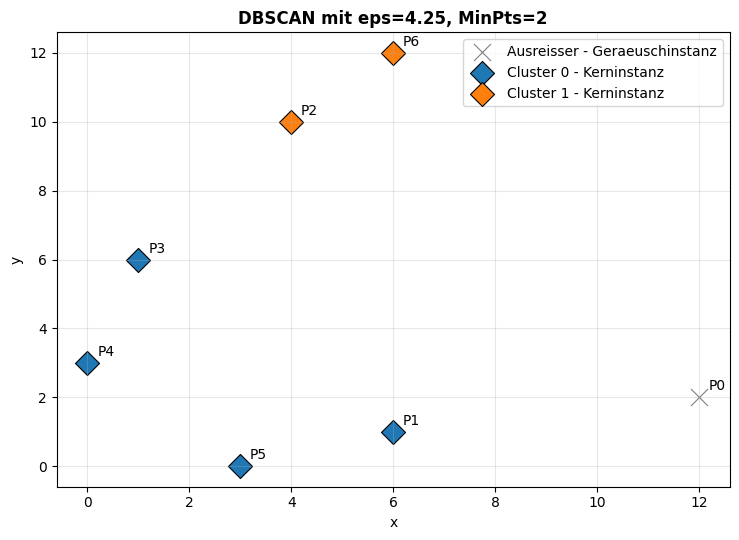

In [29]:
farben = {"Cluster 0": "tab:blue", "Cluster 1": "tab:orange", "Ausreisser": "tab:gray"}
marker = {"Kerninstanz": "D", "Grenzinstanz": "o", "Geraeuschinstanz": "x"}

fig, ax = plt.subplots(figsize=(7.5, 5.5))

for punkt, zeile in dbscan_ergebnis.iterrows():
    ax.scatter(
        zeile["x"],
        zeile["y"],
        s=150,
        color=farben[zeile["Cluster"]],
        marker=marker[zeile["Instanztyp"]],
        edgecolor="black" if zeile["Instanztyp"] != "Geraeuschinstanz" else None,
        linewidth=0.8,
        label=f'{zeile["Cluster"]} - {zeile["Instanztyp"]}',
    )
    ax.annotate(punkt, (zeile["x"], zeile["y"]), xytext=(7, 5), textcoords="offset points")

# Doppelte Legendeneintraege entfernen
handles, labels_legend = ax.get_legend_handles_labels()
eindeutig = dict(zip(labels_legend, handles))

ax.set_title(f"DBSCAN mit eps={eps}, MinPts={min_pts}", fontweight="bold")
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.grid(alpha=0.3)
ax.legend(eindeutig.values(), eindeutig.keys(), loc="best")

plt.tight_layout()
plt.show()

**Auswertung DBSCAN:**  
Mit `eps = 4.25` und `MinPts = 2` entstehen genau zwei gueltige Cluster. `P0` wird als Geraeuschinstanz erkannt, weil der Punkt zu weit von den anderen Punkten entfernt liegt. Die Cluster bestehen aus `P1, P3, P4, P5` sowie `P2, P6`. Alle Punkte in den beiden Clustern sind Kerninstanzen; Grenzinstanzen gibt es bei dieser Parametereinstellung nicht.

#### d)

In [ ]:
# Distanzmatrix nach dem DBSCAN-Clustering sortieren.
# Cluster 0 und Cluster 1 kommen zuerst, der Ausreisser P0 steht am Ende.
sortier_info = dbscan_ergebnis.copy()
sortier_info["Sortierung"] = dbscan_labels
sortier_info["Sortierung"] = sortier_info["Sortierung"].replace(-1, 99)
sortier_info = sortier_info.sort_values(["Sortierung", "x", "y"])

sortierte_punkte = sortier_info.index.tolist()
daten_sortiert = daten.loc[sortierte_punkte]

distanzmatrix_sortiert = pairwise_distances(daten_sortiert[["x", "y"]], metric="euclidean")
heatmap_labels = [f"{punkt} ({dbscan_ergebnis.loc[punkt, 'Cluster']})" for punkt in sortierte_punkte]

distanzmatrix_sortiert_df = pd.DataFrame(
    distanzmatrix_sortiert,
    index=heatmap_labels,
    columns=heatmap_labels,
)

print("Sortierte Reihenfolge der Punkte:")
display(sortier_info[["x", "y", "Cluster", "Instanztyp"]])

plt.figure(figsize=(9, 7))
sns.heatmap(
    distanzmatrix_sortiert_df,
    annot=True,
    fmt=".2f",
    cmap="YlOrRd",
    linewidths=0.5,
    cbar_kws={"label": "Euklidische Distanz"},
)

plt.title("Heatmap der Distanzmatrix nach DBSCAN-Clustern", fontweight="bold")
plt.xlabel("Sortierte Datenpunkte")
plt.ylabel("Sortierte Datenpunkte")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Interpretation der Heatmap:**  
Die Heatmap zeigt nach der Sortierung zwei erkennbare Clusterbereiche. `Cluster 1` mit `P2` und `P6` ist sehr kompakt, da die Distanz zwischen diesen beiden Punkten nur `2.83` betraegt. `Cluster 0` mit `P1, P3, P4, P5` ist weniger kompakt, aber durch nahe Nachbarschaften zusammenhaengend: `P1` liegt nah bei `P5`, `P5` nah bei `P4` und `P4` nah bei `P3`. Genau diese Dichteverkettung passt zu DBSCAN. `P0` hat zu allen anderen Punkten deutlich groessere Distanzen und wird deshalb sinnvoll als Geraeuschinstanz erkannt. Insgesamt ist das DBSCAN-Clustering fuer diesen Datensatz plausibel und gut interpretierbar, aber nicht perfekt kompakt wie ein ideales kugelfoermiges Clustering.

## Teil 2

#### a)

#### b)

#### c)

#### d)

#### e)

#### f)

#### g)

#### h)

#### i)

#### j)

#### k)

#### l)

#### m)